# 4. Structure factor (spectral correlations) 

In [1]:
import numpy as np
import pandas as pd
import os

from surface_functions import compute_structure_factor

In [2]:
z_dict = {"TimeDep": {"EW": 2, "KPZ": 3/2}, "Columnar": {"EW": 2, "KPZ": 1.36}}
alpha_dict = {"TimeDep": {"EW": 1/2, "KPZ": 1/2}, "Columnar": {"EW": 3/2, "KPZ": 1.07}}
alpha_s_dict = {"TimeDep": {"EW": 1/2, "KPZ": 1/2}, "Columnar": {"EW": 3/2, "KPZ": 1.4}}  # anomalous scaling, only for columnar noise
alpha_loc_dict = {"TimeDep": {"EW": 1/2, "KPZ": 1/2}, "Columnar": {"EW": 1, "KPZ": 0.96}} # anomalous scaling, only for columnar noise
beta_dict = {"TimeDep": {"EW": alpha_dict["TimeDep"]["EW"]/z_dict["TimeDep"]["EW"], "KPZ": alpha_dict["TimeDep"]["KPZ"]/z_dict["TimeDep"]["KPZ"]}, 
             "Columnar": {"EW": alpha_dict["Columnar"]["EW"]/z_dict["Columnar"]["EW"], "KPZ": alpha_dict["Columnar"]["KPZ"]/z_dict["Columnar"]["KPZ"]}}
delta_to_label = {"0": "EW", "atan5": "KPZ"}

## Dataframe computations

In [ ]:
summary_rows = []
for typenoise in ["TimeDep", "Columnar"]:
    
    for delta, deltaname in zip([0, np.arctan(5)], ["0", "atan5"]):

        path = f"Output{typenoise}/Solutions_delta{deltaname}.pkl"
        if not os.path.exists(path):
            print(f"File {path} not found, skipping.")
            continue

        print(f"## {typenoise} – Delta {deltaname}")

        # Load previously saved simulations
        df = pd.read_pickle(path)

        structurefactor_list = []  # used to compute per-sim roughness

        # Loop over simulations (one per seed / row)
        for _, row in df.iterrows():
            t = row["t"]
            phases = row["phases"]

            # ensure array, not list-of-lists
            structurefactor = np.asarray(compute_structure_factor(phases), dtype=float)

            structurefactor_list.append(structurefactor)

        # Avoid chained-assignment issues
        df = df.copy()
        df["structurefactor"] = structurefactor_list

        # Save back the updated simulations DataFrame (with roughness column)
        df.to_pickle(path)

        ## AVERAGE STRUCTURE FACTOR PER (K, L, T) ##
        # group by K, L, T and compute mean structure factor for each group
        for (K_val, L_val, T_val), group in df.groupby(["K", "L", "T"]):
            structurefactor_arrays = [np.asarray(r, dtype=float) for r in group["structurefactor"]]
            mean_structurefactor = np.mean(np.stack(structurefactor_arrays, axis=0), axis=0)
            
            avg_id = f"{typenoise}_delta{deltaname}_L{L_val}_K{K_val}_T{T_val}_M{len(group)}"

            summary_rows.append(
                {
                    "avg_id": avg_id,
                    "mean_structurefactor": mean_structurefactor,
                }
            )

        print("Seeds (index):", df.index.tolist())
        # print("Number of simulations:", M)
        print("Columns:", df.columns.tolist())

## TimeDep – Delta 0
Seeds (index): ['L500_K1_seed78375102', 'L500_K1_seed48022158', 'L500_K1_seed21517135', 'L500_K1_seed73450932', 'L500_K1_seed5701930', 'L500_K0.01_seed66323775', 'L500_K1_seed66955334', 'L500_K0.01_seed51276577', 'L500_K1_seed66776927', 'L500_K0.01_seed39155229', 'L500_K1_seed10688739', 'L500_K0.01_seed74911657', 'L500_K1_seed14995512', 'L500_K0.01_seed92687884', 'L500_K1_seed11013623', 'L500_K0.01_seed77570756', 'L500_K1_seed26524819', 'L500_K0.01_seed87634771', 'L500_K1_seed61884301', 'L500_K0.01_seed87439695', 'L500_K1_seed70493549', 'L500_K0.01_seed46007736', 'L500_K1_seed16437593', 'L500_K0.01_seed55248971', 'L500_K1_seed13595782', 'L500_K0.01_seed18901207', 'L500_K1_seed41894445', 'L500_K0.01_seed90297636', 'L500_K1_seed7367704', 'L500_K0.01_seed24097069', 'L500_K1_seed78608552', 'L500_K0.01_seed73001616', 'L500_K1_seed46449722', 'L500_K0.01_seed31008285', 'L500_K1_seed22480058', 'L500_K1_seed4733608', 'L500_K0.01_seed39831824', 'L500_K1_seed92871047', 'L500_

In [6]:
# === add this after the loops ===
avg_df_path = "AverageSims.pkl"
avg_df = pd.read_pickle(avg_df_path)

new_avg = pd.DataFrame(summary_rows).set_index("avg_id")
avg_df.loc[new_avg.index, "mean_structurefactor"] = new_avg["mean_structurefactor"]

avg_df.to_pickle(avg_df_path)

In [7]:
avg_df

,typenoise,delta,deltaname,K,L,t,M,T,mean_roughness,mean_roughness2,mean_heightheight,mean_structurefactor
avg_id,,,,,,,,,,,,
TimeDep_delta0_L500_K0.01_T20000_M500,TimeDep,0.000000,0,0.01,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,20000,"[0.0, 0.09932794776024303, 0.12445710235930987...","[0.0, 0.09937158963203278, 0.12451669747551469...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_delta0_L125_K1.0_T20000_M1000,TimeDep,0.000000,0,1.00,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",1000,20000,"[0.0, 0.06206535180620217, 0.06962088956407118...","[0.0, 0.06224447417192954, 0.06987538331690908...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_delta0_L250_K1.0_T20000_M500,TimeDep,0.000000,0,1.00,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,20000,"[0.0, 0.06185445817599045, 0.0696865309816036,...","[0.0, 0.061951592706644056, 0.0698286189854493...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_delta0_L500_K1.0_T20000_M500,TimeDep,0.000000,0,1.00,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,20000,"[0.0, 0.062281209851627814, 0.0703404523305143...","[0.0, 0.062330873676472595, 0.0704074790636151...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_delta0_L1000_K1.0_T2000_M500,TimeDep,0.000000,0,1.00,1000,"[0.0, 1.000005000025, 1.6000080000400003, 2.56...",500,2000,"[0.0, 0.062289693394964187, 0.0704964066887407...","[0.0, 0.06231310748464172, 0.070528464896139, ...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_deltaatan5_L500_K0.01_T20000_M500,TimeDep,1.373401,atan5,0.01,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,20000,"[0.0, 0.10014740577543957, 0.1261770083222738,...","[0.0, 0.10019634453950993, 0.12623155432190383...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_deltaatan5_L125_K1.0_T20000_M1000,TimeDep,1.373401,atan5,1.00,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",1000,20000,"[0.0, 0.08497581574082771, 0.10016716020392952...","[0.0, 0.085169740061077, 0.10039858844247401, ...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_deltaatan5_L250_K1.0_T20000_M500,TimeDep,1.373401,atan5,1.00,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,20000,"[0.0, 0.08525314007445625, 0.10040309251048023...","[0.0, 0.08534060165610576, 0.10051558946041181...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_deltaatan5_L500_K1.0_T20000_M500,TimeDep,1.373401,atan5,1.00,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,20000,"[0.0, 0.08538735713321526, 0.10092130285727816...","[0.0, 0.08543379532608593, 0.10098882300685771...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."


## Inspection of the computed quantities

In [9]:
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(["science","no-latex"])

%load_ext autoreload
%autoreload 2

from plotting_helpers import plot_structurefactor_evolution, plot_structurefactor_collapse, analytical_Larkin_structurefactor

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
avg_df_path = "AverageSims.pkl"
avg_df = pd.read_pickle(avg_df_path)

L = 1000
T = 20000
Ks = [1, 40]

In [5]:
markerdict = {500: "o", 250: "x", 125: "^", 1000: "s"}

In [6]:
# Adjustment to the crossover time: t_x = tx * L**z (BY HAND for Ks=[1,40])
tx = {"TimeDep": {"EW": 1/30, "KPZ": 1/4}, "Columnar": {"EW": 1/800, "KPZ": 1/20}}

/home/gonzalo/Pruebas/RoughKuramoto/plotting_helpers.py:378: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax[1,0].set_ylim(0,1e3)
/home/gonzalo/Pruebas/RoughKuramoto/plotting_helpers.py:379: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax[1,1].set_ylim(0,1e5)
/home/gonzalo/Pruebas/RoughKuramoto/plotting_helpers.py:32: RuntimeWarning: divide by zero encountered in divide
  S_phi = ((2 * np.pi)**d * 2 * sigma / (nu**2 * k**4)) * (1 - np.exp(- nu * k**2 * t))**2
/home/gonzalo/Pruebas/RoughKuramoto/plotting_helpers.py:32: RuntimeWarning: invalid value encountered in multiply
  S_phi = ((2 * np.pi)**d * 2 * sigma / (nu**2 * k**4)) * (1 - np.exp(- nu * k**2 * t))**2


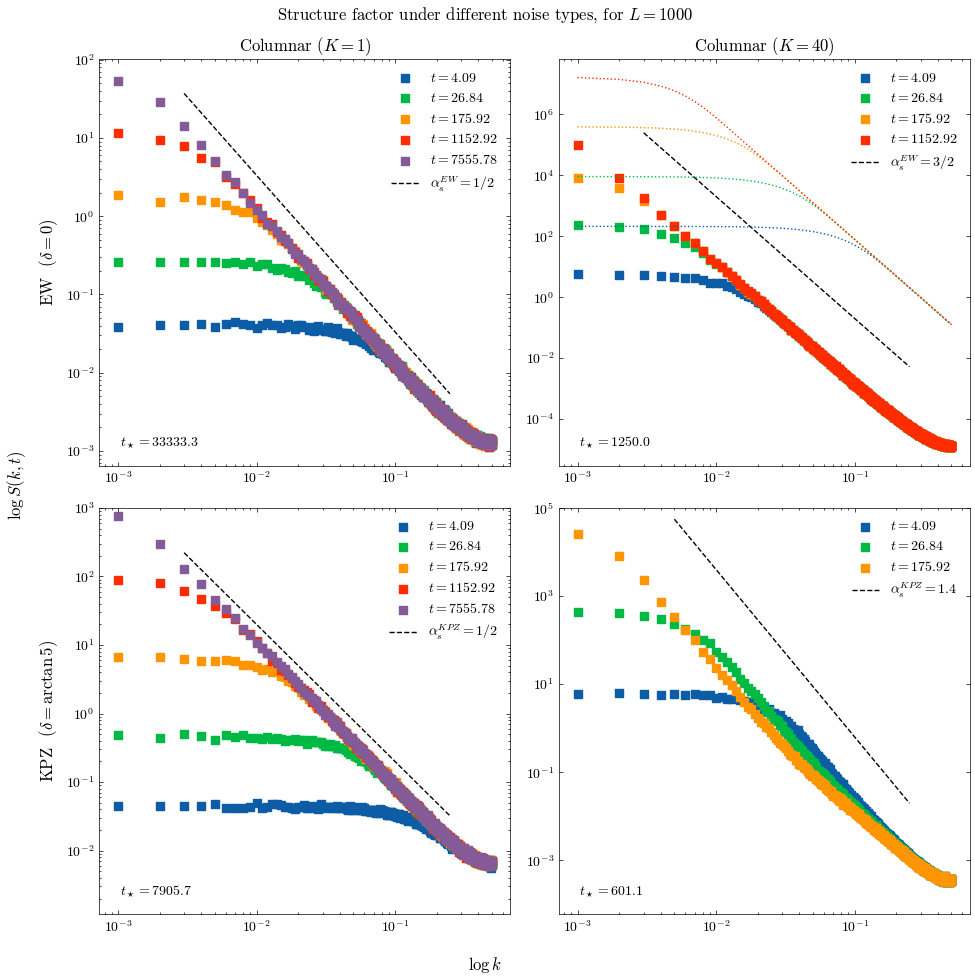

In [7]:
plot_structurefactor_evolution(avg_df, L, T, tx, Ks, analytical=True)

Text(0.5, 1.0, 'Analytical Larkin structure factor at different times')

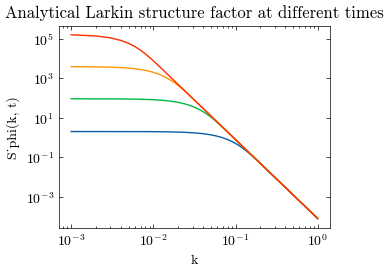

In [12]:
# krange = np.linspace(0.1, 100, 1000)

nu = 40.0
sigma = 1.0/100

krange = np.linspace(1e-3, 1, 1000)

Sphi_50 = analytical_Larkin_structurefactor(krange, 4, sigma=sigma, nu=nu, d=1)
Sphi_80 = analytical_Larkin_structurefactor(krange, 27, sigma=sigma, nu=nu, d=1)
Sphi_200 = analytical_Larkin_structurefactor(krange, 176, sigma=sigma, nu=nu, d=1)
Sphi_500 = analytical_Larkin_structurefactor(krange, 1153, sigma=sigma, nu=nu, d=1)
plt.plot(krange, Sphi_50)
plt.plot(krange, Sphi_80)
plt.plot(krange, Sphi_200)
plt.plot(krange, Sphi_500)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("k")
plt.ylabel("S_phi(k, t)")
plt.title("Analytical Larkin structure factor at different times")

#### Family-Vicsek collapse of the structure factor

<unknown>:214: SyntaxWarning: invalid escape sequence '\s'
<unknown>:287: SyntaxWarning: invalid escape sequence '\s'
<unknown>:362: SyntaxWarning: invalid escape sequence '\s'
<unknown>:446: SyntaxWarning: invalid escape sequence '\s'
<unknown>:214: SyntaxWarning: invalid escape sequence '\s'
<unknown>:287: SyntaxWarning: invalid escape sequence '\s'
<unknown>:362: SyntaxWarning: invalid escape sequence '\s'
<unknown>:446: SyntaxWarning: invalid escape sequence '\s'


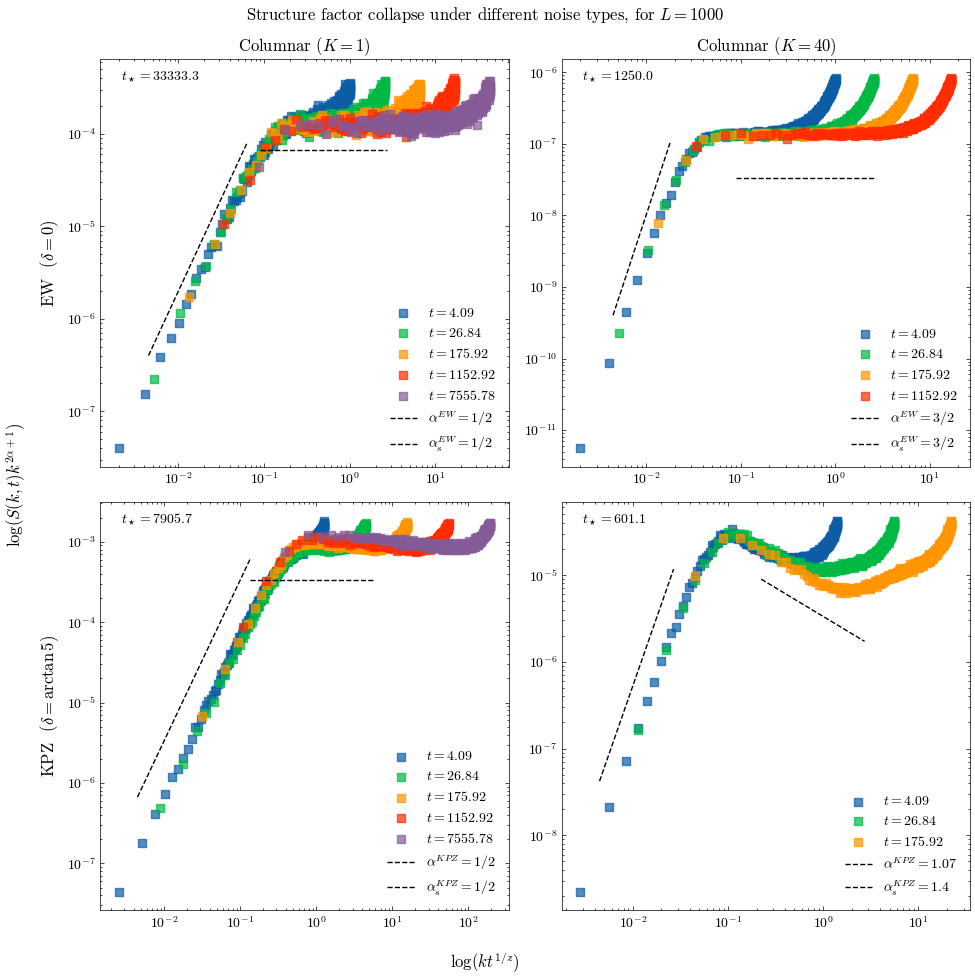

In [12]:
plot_structurefactor_collapse(avg_df, L, T, tx, Ks)